In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('https://gist.githubusercontent.com/curran/4b59d1046d9e66f2787780ad51a1cd87/raw/9ec906b78a98cf300947a37b56cfe70d01183200/data.tsv', sep='\t')
data.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


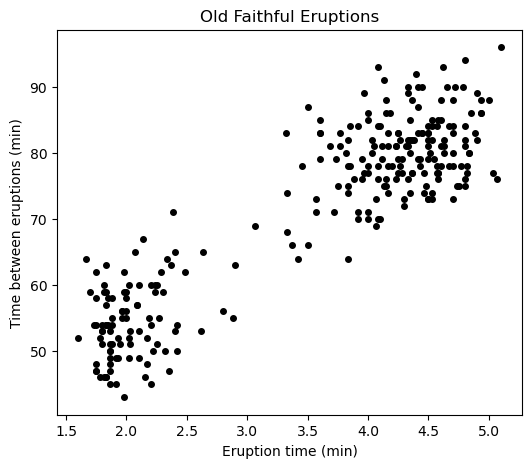

In [4]:
plt.figure(figsize=(6, 5))
plt.plot(data['eruptions'], data['waiting'], 'o', c='black', markersize=4)
plt.xlabel('Eruption time (min)')
plt.ylabel('Time between eruptions (min)')
plt.title('Old Faithful Eruptions')
plt.show()

In [5]:
eruptions = data['eruptions'].tolist()

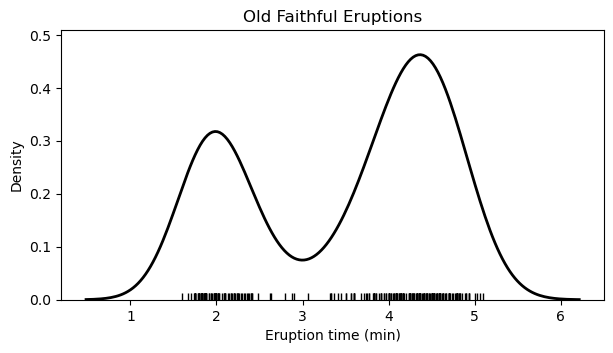

In [6]:
plt.figure(figsize=(7, 3.5))
sns.kdeplot(eruptions, color='black', label='Eruptions',lw=2, ls='-')
sns.rugplot(eruptions, color='black', label='X1')
plt.xlabel('Eruption time (min)')
plt.ylabel('Density')
plt.title('Old Faithful Eruptions')
plt.show()

In [7]:
# Initialize the parameters

mu1_hat = data['eruptions'].describe()['25%']
mu2_hat = data['eruptions'].describe()['75%']
sigma1_hat = 1
sigma2_hat = 1
pi1_hat = 0.5
pi2_hat = 0.5

prior_class_0 = 0.5
prior_class_1 = 0.5

mu1_hat, mu2_hat, sigma1_hat, sigma2_hat, pi1_hat, pi2_hat

(2.16275, 4.45425, 1, 1, 0.5, 0.5)

In [8]:
import scipy

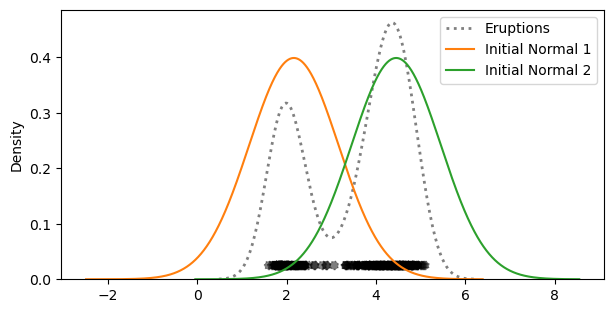

In [9]:
# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1_hat, sigma1_hat, 100000)
samples_2 = np.random.normal(mu2_hat, sigma2_hat, 100000)

y_normal_1 = scipy.stats.norm(mu1_hat, sigma1_hat).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_hat, sigma2_hat).pdf(np.sort(samples_2))

plt.figure(figsize=(7, 3.5))
y_value = 0.025
y = np.zeros_like(eruptions) + y_value

sns.kdeplot(eruptions, color='gray', label='Eruptions',lw=2, ls='dotted')
plt.scatter(eruptions, y, ls='dotted', marker='o', c='black', alpha=0.5)
plt.plot(np.sort(samples_1), y_normal_1, c='tab:orange', label='Initial Normal 1')
plt.plot(np.sort(samples_2), y_normal_2, c='tab:green', label='Initial Normal 2')
plt.legend()
plt.show()

In [10]:
x = eruptions[0]
x

3.6

In [11]:
1/np.sqrt(2*3.14*(sigma1_hat**2))*np.exp(-((x-mu1_hat)**2)/(2*(sigma1_hat**2)))

0.14205673321478066

In [12]:
scipy.stats.norm(mu1_hat,sigma1_hat).pdf(x)

0.1420207202951014

In [13]:
mu1_hat = data['eruptions'].describe()['25%']
mu2_hat = data['eruptions'].describe()['75%']
sigma1_hat = 1
sigma2_hat = 1
pi1_hat = 0.5
pi2_hat = 0.5

prior_class_0 = 0.5
prior_class_1 = 0.5

mu1_hat, mu2_hat, sigma1_hat, sigma2_hat, pi1_hat, pi2_hat

px_class1 = [ scipy.stats.norm(mu1_hat,sigma1_hat).pdf(xi) for xi in eruptions]
px_class2 = [ scipy.stats.norm(mu2_hat,sigma2_hat).pdf(xi) for xi in eruptions]

log_likelihood = np.sum(np.log(np.array([[prior_class_0*i for i in px_class1], [prior_class_1*i for i in px_class2]]).sum(axis=0)))

In [20]:
px_class1_manual = [1 / np.sqrt(2 * np.pi * sigma1_hat**2) * np.exp(-((xi - mu1_hat)**2) / (2 * sigma1_hat**2)) for xi in eruptions]
px_class2_manual = [1 / np.sqrt(2 * np.pi * sigma2_hat**2) * np.exp(-((xi - mu2_hat)**2) / (2 * sigma2_hat**2)) for xi in eruptions]

In [21]:
# Manual calculation is the same as the library calculation
np.all(list(map(lambda x: np.isclose(*x,1e-1) , zip(px_class1, px_class1_manual)))),\
np.all(list(map(lambda x: np.isclose(*x,1e-1) , zip(px_class2, px_class2_manual))))

(True, True)

In [22]:
# The posterior probabilities (posteriors_class1 and posteriors_class2) represent the relative contributions or responsibilities of each class for every data point.

# Each posterior value represents the probability of a class given the data point x_i

def calculate_posterior(px1, px2, prior_class_0, prior_class_1):
    p_class1_x1 = (px1*prior_class_0)/(px1*prior_class_0 + px2*prior_class_1)
    p_class2_x1 = (px2*prior_class_1)/(px1*prior_class_0 + px2*prior_class_1)
    return p_class1_x1, p_class2_x1

posteriors = [calculate_posterior(px1, px2, prior_class_0, prior_class_1) for px1, px2 in zip(px_class1, px_class2)]
posteriors_class1 = [i[0] for i in posteriors]
posteriors_class2 = [i[1] for i in posteriors]

np.all(np.isclose(np.sum(list(zip(posteriors_class1, posteriors_class2)),1),1))

True

In [23]:
# Standardize the posteriors to sum to 1
posteriors_class1_std = posteriors_class1/np.sum(posteriors_class1)
posteriors_class2_std = posteriors_class2/np.sum(posteriors_class2)

np.sum(posteriors_class1_std), np.sum(posteriors_class2_std)

(1.0, 1.0)

### Maximization step

In [24]:
mu1_hat = sum(x * posterior for x, posterior in zip(eruptions, posteriors_class1)) / sum(posteriors_class1)
var_1 = sum(posterior * (x - mu1_hat)**2 for x, posterior in zip(eruptions, posteriors_class1)) / sum(posteriors_class1)
sigma1_hat = np.sqrt(var_1)

mu1_hat, sigma1_hat

(2.4014780603174395, 0.8186049050303101)

In [25]:
mu2_hat = sum(x * posterior for x, posterior in zip(eruptions, posteriors_class2)) / sum(posteriors_class2)
var_2 = sum(posterior * (x - mu2_hat)**2 for x, posterior in zip(eruptions, posteriors_class2)) / sum(posteriors_class2)
sigma2_hat = np.sqrt(var_2)

mu2_hat, sigma2_hat


(4.2614940568349295, 0.553160682328054)

In [26]:
mu1_hat = data['eruptions'].describe()['25%']
mu2_hat = data['eruptions'].describe()['75%']
sigma1_hat = 1
sigma2_hat = 1
pi1_hat = 0.5
pi2_hat = 0.5

prior_class_0 = 0.5
prior_class_1 = 0.5

mu1_hat, mu2_hat, sigma1_hat, sigma2_hat, pi1_hat, pi2_hat

(2.16275, 4.45425, 1, 1, 0.5, 0.5)

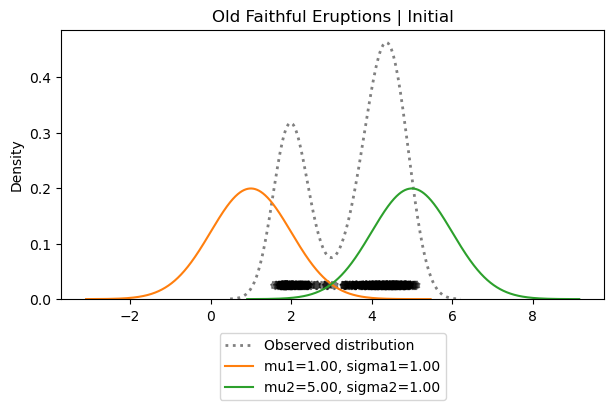

In [27]:
mu1_hat, mu2_hat = 1, 5
sigma1_hat, sigma2_hat = 1, 1
pi1_hat, pi2_hat = 0.5, 0.5

# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1_hat, sigma1_hat, 100000)
samples_2 = np.random.normal(mu2_hat, sigma2_hat, 100000)

y_normal_1 = scipy.stats.norm(mu1_hat, sigma1_hat).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_hat, sigma2_hat).pdf(np.sort(samples_2))

y_normal_1_scaled = y_normal_1 * pi1_hat
y_normal_2_scaled = y_normal_2 * pi2_hat


plt.figure(figsize=(7, 3.5))
plt.title('Old Faithful Eruptions | Initial')
y_value = 0.025
y = np.zeros_like(eruptions) + y_value

sns.kdeplot(eruptions, color='gray', label='Observed distribution',lw=2, ls='dotted')
plt.scatter(eruptions, y, ls='dotted', marker='o', c='black', alpha=0.5)
plt.plot(np.sort(samples_1), y_normal_1_scaled, c='tab:orange', label=f'mu1={mu1_hat:.2f}, sigma1={sigma1_hat:.2f}')
plt.plot(np.sort(samples_2), y_normal_2_scaled, c='tab:green', label=f'mu2={mu2_hat:.2f}, sigma2={sigma2_hat:.2f}')
plt.legend(bbox_to_anchor=(0.5, -0.25), loc='center')
plt.show()

In [28]:
log_likelihood_list = []
for i in range(20):
    ## Expectation step

    px_class1 = [ scipy.stats.norm(mu1_hat,sigma1_hat).pdf(xi) for xi in eruptions]
    px_class2 = [ scipy.stats.norm(mu2_hat,sigma2_hat).pdf(xi) for xi in eruptions]

    log_likelihood = np.sum(np.log(np.array([[prior_class_0*i for i in px_class1], [prior_class_1*i for i in px_class2]]).sum(axis=0)))

    posteriors = [calculate_posterior(px1, px2, prior_class_0, prior_class_1) for px1, px2 in zip(px_class1, px_class2)]

    posteriors_class1 = [i[0] for i in posteriors]
    posteriors_class2 = [i[1] for i in posteriors]


    # Standardize the posteriors to sum to 1
    posteriors_class1_std = posteriors_class1/np.sum(posteriors_class1)
    posteriors_class2_std = posteriors_class2/np.sum(posteriors_class2)


    ## Maximization step

    mu1_hat = sum(x * posterior for x, posterior in zip(eruptions, posteriors_class1)) / sum(posteriors_class1)
    var_1 = sum(posterior * (x - mu1_hat)**2 for x, posterior in zip(eruptions, posteriors_class1)) / sum(posteriors_class1)
    sigma1_hat = np.sqrt(var_1)

    mu2_hat = sum(x * posterior for x, posterior in zip(eruptions, posteriors_class2)) / sum(posteriors_class2)
    var_2 = sum(posterior * (x - mu2_hat)**2 for x, posterior in zip(eruptions, posteriors_class2)) / sum(posteriors_class2)
    sigma2_hat = np.sqrt(var_2)


    # Update mixing proportions
    pi1_hat = sum(posteriors_class1) / len(eruptions)
    pi2_hat = sum(posteriors_class2) / len(eruptions)
    
    # Update priors if needed elsewhere
    prior_class_0 = pi1_hat
    prior_class_1 = pi2_hat

    log_likelihood_list.append(log_likelihood)    

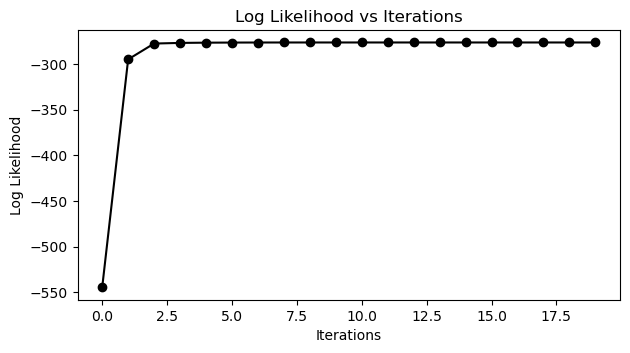

In [29]:
plt.figure(figsize=(7, 3.5))
plt.plot( log_likelihood_list, marker='o', color='k')
plt.xlabel('Iterations')
plt.ylabel('Log Likelihood')
plt.title('Log Likelihood vs Iterations')
plt.show()

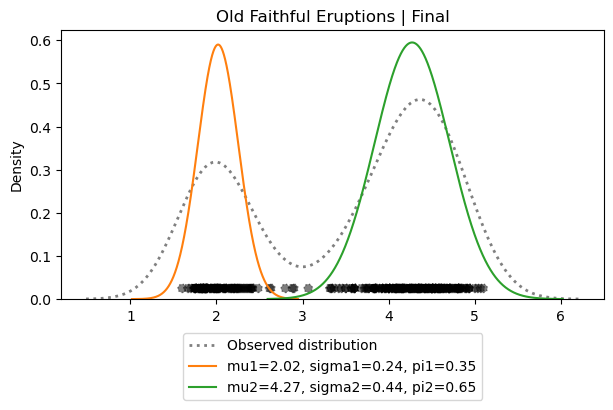

In [30]:
# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1_hat, sigma1_hat, int(pi1_hat*100000))
samples_2 = np.random.normal(mu2_hat, sigma2_hat, int(pi2_hat*100000))


# samples_1 = np.random.normal(mu1_hat, sigma1_hat, 100000)
# samples_2 = np.random.normal(mu2_hat, sigma2_hat, 100000)

y_normal_1 = scipy.stats.norm(mu1_hat, sigma1_hat).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_hat, sigma2_hat).pdf(np.sort(samples_2))

y_normal_1_scaled = y_normal_1 * pi1_hat
y_normal_2_scaled = y_normal_2 * pi2_hat


plt.figure(figsize=(7, 3.5))
plt.title('Old Faithful Eruptions | Final')
y_value = 0.025
y = np.zeros_like(eruptions) + y_value

sns.kdeplot(eruptions, color='gray', label='Observed distribution',lw=2, ls='dotted')
plt.scatter(eruptions, y, ls='dotted', marker='o', c='black', alpha=0.5)

plt.plot(np.sort(samples_1), y_normal_1_scaled, c='tab:orange', label=f'mu1={mu1_hat:.2f}, sigma1={sigma1_hat:.2f}, pi1={pi1_hat:.2f}')
plt.plot(np.sort(samples_2), y_normal_2_scaled, c='tab:green', label=f'mu2={mu2_hat:.2f}, sigma2={sigma2_hat:.2f}, pi2={pi2_hat:.2f}')

plt.legend(bbox_to_anchor=(0.5, -0.25), loc='center')
plt.show()

####

## For the Waiting time

In [31]:
waiting = data['waiting'].tolist()

In [32]:
mu1_hat = data['waiting'].describe()['25%']
mu2_hat = data['waiting'].describe()['75%']
sigma1_hat = data['waiting'].describe()['std']
sigma2_hat = data['waiting'].describe()['std']
pi1_hat = 0.5
pi2_hat = 0.5

prior_class_0 = 0.5
prior_class_1 = 0.5

mu1_hat, mu2_hat, sigma1_hat, sigma2_hat, pi1_hat, pi2_hat

(58.0, 82.0, 13.594973789999397, 13.594973789999397, 0.5, 0.5)

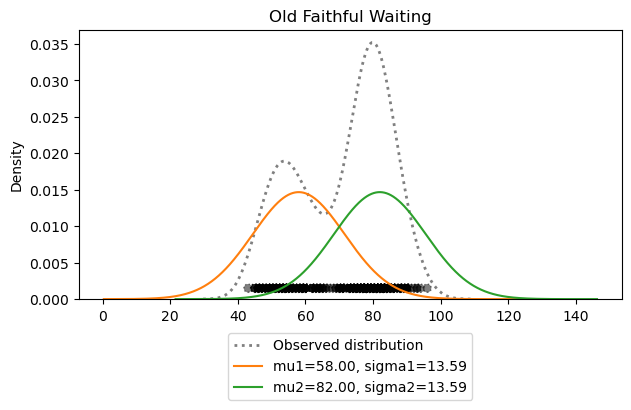

In [35]:
# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1_hat, sigma1_hat, 100000)
samples_2 = np.random.normal(mu2_hat, sigma2_hat, 100000)

y_normal_1 = scipy.stats.norm(mu1_hat, sigma1_hat).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_hat, sigma2_hat).pdf(np.sort(samples_2))

y_normal_1_scaled = y_normal_1 * pi1_hat
y_normal_2_scaled = y_normal_2 * pi2_hat


plt.figure(figsize=(7, 3.5))
plt.title('Old Faithful Waiting')
y_value = 0.0015
y = np.zeros_like(eruptions) + y_value

sns.kdeplot(waiting, color='gray', label='Observed distribution',lw=2, ls='dotted')
plt.scatter(waiting, y, ls='dotted', marker='o', c='black', alpha=0.5)
plt.plot(np.sort(samples_1), y_normal_1_scaled, c='tab:orange', label=f'mu1={mu1_hat:.2f}, sigma1={sigma1_hat:.2f}')
plt.plot(np.sort(samples_2), y_normal_2_scaled, c='tab:green', label=f'mu2={mu2_hat:.2f}, sigma2={sigma2_hat:.2f}')
plt.legend(bbox_to_anchor=(0.5, -0.25), loc='center')
plt.show()

In [36]:
X = waiting.copy()
log_likelihood_list = []
for i in range(20):
    ## Expectation step

    px_class1 = [ scipy.stats.norm(mu1_hat,sigma1_hat).pdf(xi) for xi in X]
    px_class2 = [ scipy.stats.norm(mu2_hat,sigma2_hat).pdf(xi) for xi in X]

    log_likelihood = np.sum(np.log(np.array([[prior_class_0*i for i in px_class1], [prior_class_1*i for i in px_class2]]).sum(axis=0)))

    posteriors = [calculate_posterior(px1, px2, prior_class_0, prior_class_1) for px1, px2 in zip(px_class1, px_class2)]

    posteriors_class1 = [i[0] for i in posteriors]
    posteriors_class2 = [i[1] for i in posteriors]


    # Standardize the posteriors to sum to 1
    posteriors_class1_std = posteriors_class1/np.sum(posteriors_class1)
    posteriors_class2_std = posteriors_class2/np.sum(posteriors_class2)


    ## Maximization step

    mu1_hat = sum(x * posterior for x, posterior in zip(X, posteriors_class1)) / sum(posteriors_class1)
    var_1 = sum(posterior * (x - mu1_hat)**2 for x, posterior in zip(X, posteriors_class1)) / sum(posteriors_class1)
    sigma1_hat = np.sqrt(var_1)

    mu2_hat = sum(x * posterior for x, posterior in zip(X, posteriors_class2)) / sum(posteriors_class2)
    var_2 = sum(posterior * (x - mu2_hat)**2 for x, posterior in zip(X, posteriors_class2)) / sum(posteriors_class2)
    sigma2_hat = np.sqrt(var_2)


    # Update mixing proportions
    pi1_hat = sum(posteriors_class1) / len(X)
    pi2_hat = sum(posteriors_class2) / len(X)
    
    # Update priors if needed elsewhere
    prior_class_0 = pi1_hat
    prior_class_1 = pi2_hat

    log_likelihood_list.append(log_likelihood)    

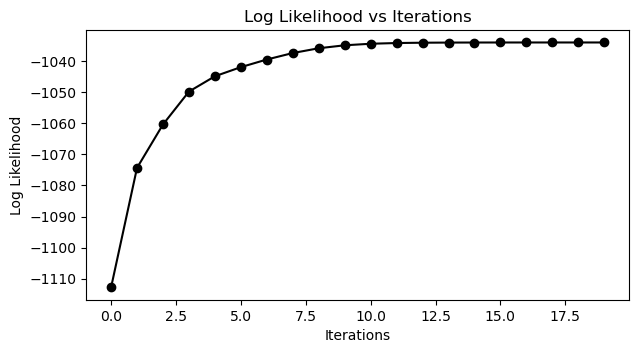

In [37]:
plt.figure(figsize=(7, 3.5))
plt.plot( log_likelihood_list, marker='o', color='k')
plt.xlabel('Iterations')
plt.ylabel('Log Likelihood')
plt.title('Log Likelihood vs Iterations')
plt.show()

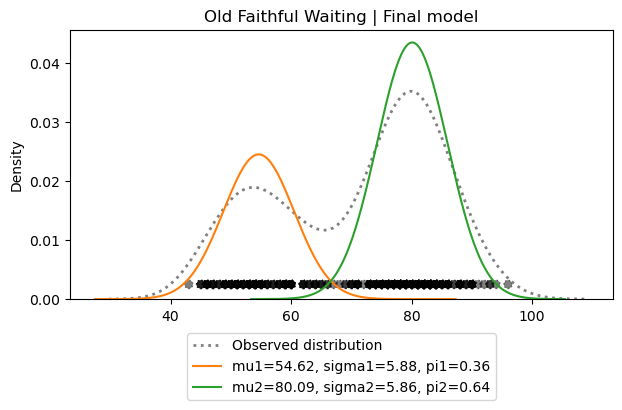

In [38]:
# sample 100000 times from this two initial normal distribution 
samples_1 = np.random.normal(mu1_hat, sigma1_hat, 100000)
samples_2 = np.random.normal(mu2_hat, sigma2_hat, 100000)

y_normal_1 = scipy.stats.norm(mu1_hat, sigma1_hat).pdf(np.sort(samples_1))
y_normal_2 = scipy.stats.norm(mu2_hat, sigma2_hat).pdf(np.sort(samples_2))

y_normal_1_scaled = y_normal_1 * pi1_hat
y_normal_2_scaled = y_normal_2 * pi2_hat


plt.figure(figsize=(7, 3.5))
plt.title('Old Faithful Waiting | Final model')
y_value = 0.0025
y = np.zeros_like(X) + y_value

sns.kdeplot(X, color='gray', label='Observed distribution',lw=2, ls='dotted')
plt.scatter(X, y, ls='dotted', marker='o', c='black', alpha=0.5)

plt.plot(np.sort(samples_1), y_normal_1_scaled, c='tab:orange', label=f'mu1={mu1_hat:.2f}, sigma1={sigma1_hat:.2f}, pi1={pi1_hat:.2f}')
plt.plot(np.sort(samples_2), y_normal_2_scaled, c='tab:green', label=f'mu2={mu2_hat:.2f}, sigma2={sigma2_hat:.2f}, pi2={pi2_hat:.2f}')

plt.legend(bbox_to_anchor=(0.5, -0.25), loc='center')
plt.show()

In [40]:
mu1_hat, mu2_hat

(54.62105309410898, 80.09498555610702)